# Artificial Neural Networks and Deep Learning

## Homework 2 - FORmidable
---

## ⚙️ Import Libraries

In [1]:
# Hi, in this baseline notebook you will find comments that for simplicity will not be re-written in the next notebooks :)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress INFO/WARNING/ERROR messages

import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras as tfk
from keras import layers as tfkl
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async" # Improve memory management and GPU utilization during model training
print(f"GPU devices: {len(tf.config.list_physical_devices('GPU'))}")

from keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16') # Set global policy to mixed precision for faster computation and less memory usage

# Set seed for reproducibility
np.random.seed(42) 
tf.random.set_seed(42) 

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tfk.__version__}")

on_kaggle = True # Set this to True when running on Kaggle, for the data paths to be correct

GPU devices: 2
TensorFlow version: 2.16.1
Keras version: 3.3.3


## ⏳ Load and Visualize the Data

In [2]:
if (on_kaggle):
    %cd "/kaggle/input"
    data = np.load("mars-dataset/mars_for_students.npz")
else: 
    data = np.load("mars_for_students.npz")

training_set = data["training_set"]

X_train_original = training_set[:, 0]
y_train_original = training_set[:, 1]
X_test_original = data["test_set"]

print(f"Training X shape: {X_train_original.shape}")
print(f"Training y shape: {y_train_original.shape}")
print(f"Test X shape: {X_test_original.shape}")

/kaggle/input
Training X shape: (2615, 64, 128)
Training y shape: (2615, 64, 128)
Test X shape: (10022, 64, 128)


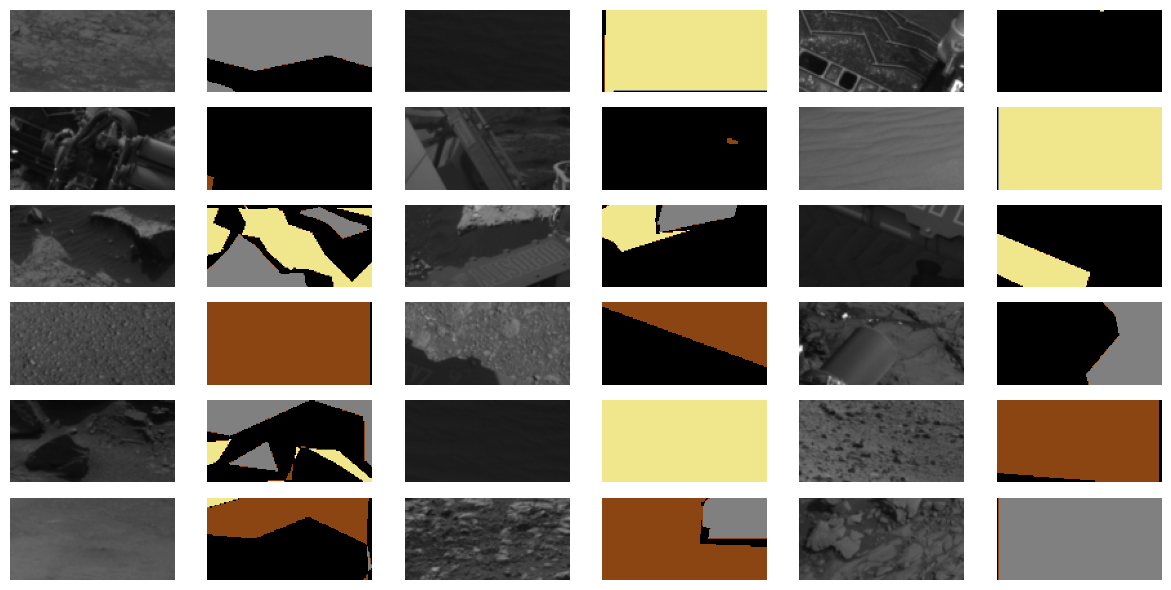

In [3]:
# Define colors and names for each label
colors = ['black', 'saddlebrown', 'gray', 'khaki', 'blue']
label_names = ['background', 'soil', 'bedrock', 'sand', 'big rock']

# Create a colormap
cmap = plt.cm.colors.ListedColormap(colors)

def plot_image_label(images, label_names, num_rows, num_cols, range_max):
    # Visualize images with their labels
    _, axes = plt.subplots(num_rows, 2 * num_cols, figsize=(4*num_cols, num_rows))
    
    for i in range(num_rows):
        for j in range(num_cols):
            idx = i * num_cols + j
            axes[i, j * 2].imshow(images[idx], cmap='gray', vmin=0, vmax=range_max)
            axes[i, j * 2].axis('off')
            axes[i, j * 2 + 1].imshow(label_names[idx], cmap=cmap, vmin=0, vmax=4)
            axes[i, j * 2 + 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
def plot_images(images, num_rows, num_cols, range_max):
    # Visualize images
    _, axes = plt.subplots(num_rows, num_cols, figsize=(2*num_cols, num_rows))
    
    for i in range(num_rows):
        for j in range(num_cols):
            idx = i * num_cols + j
            axes[i, j].imshow(images[idx], cmap='gray', vmin=0, vmax=range_max)
            axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

plot_image_label(X_train_original, y_train_original, 6, 3, 255)

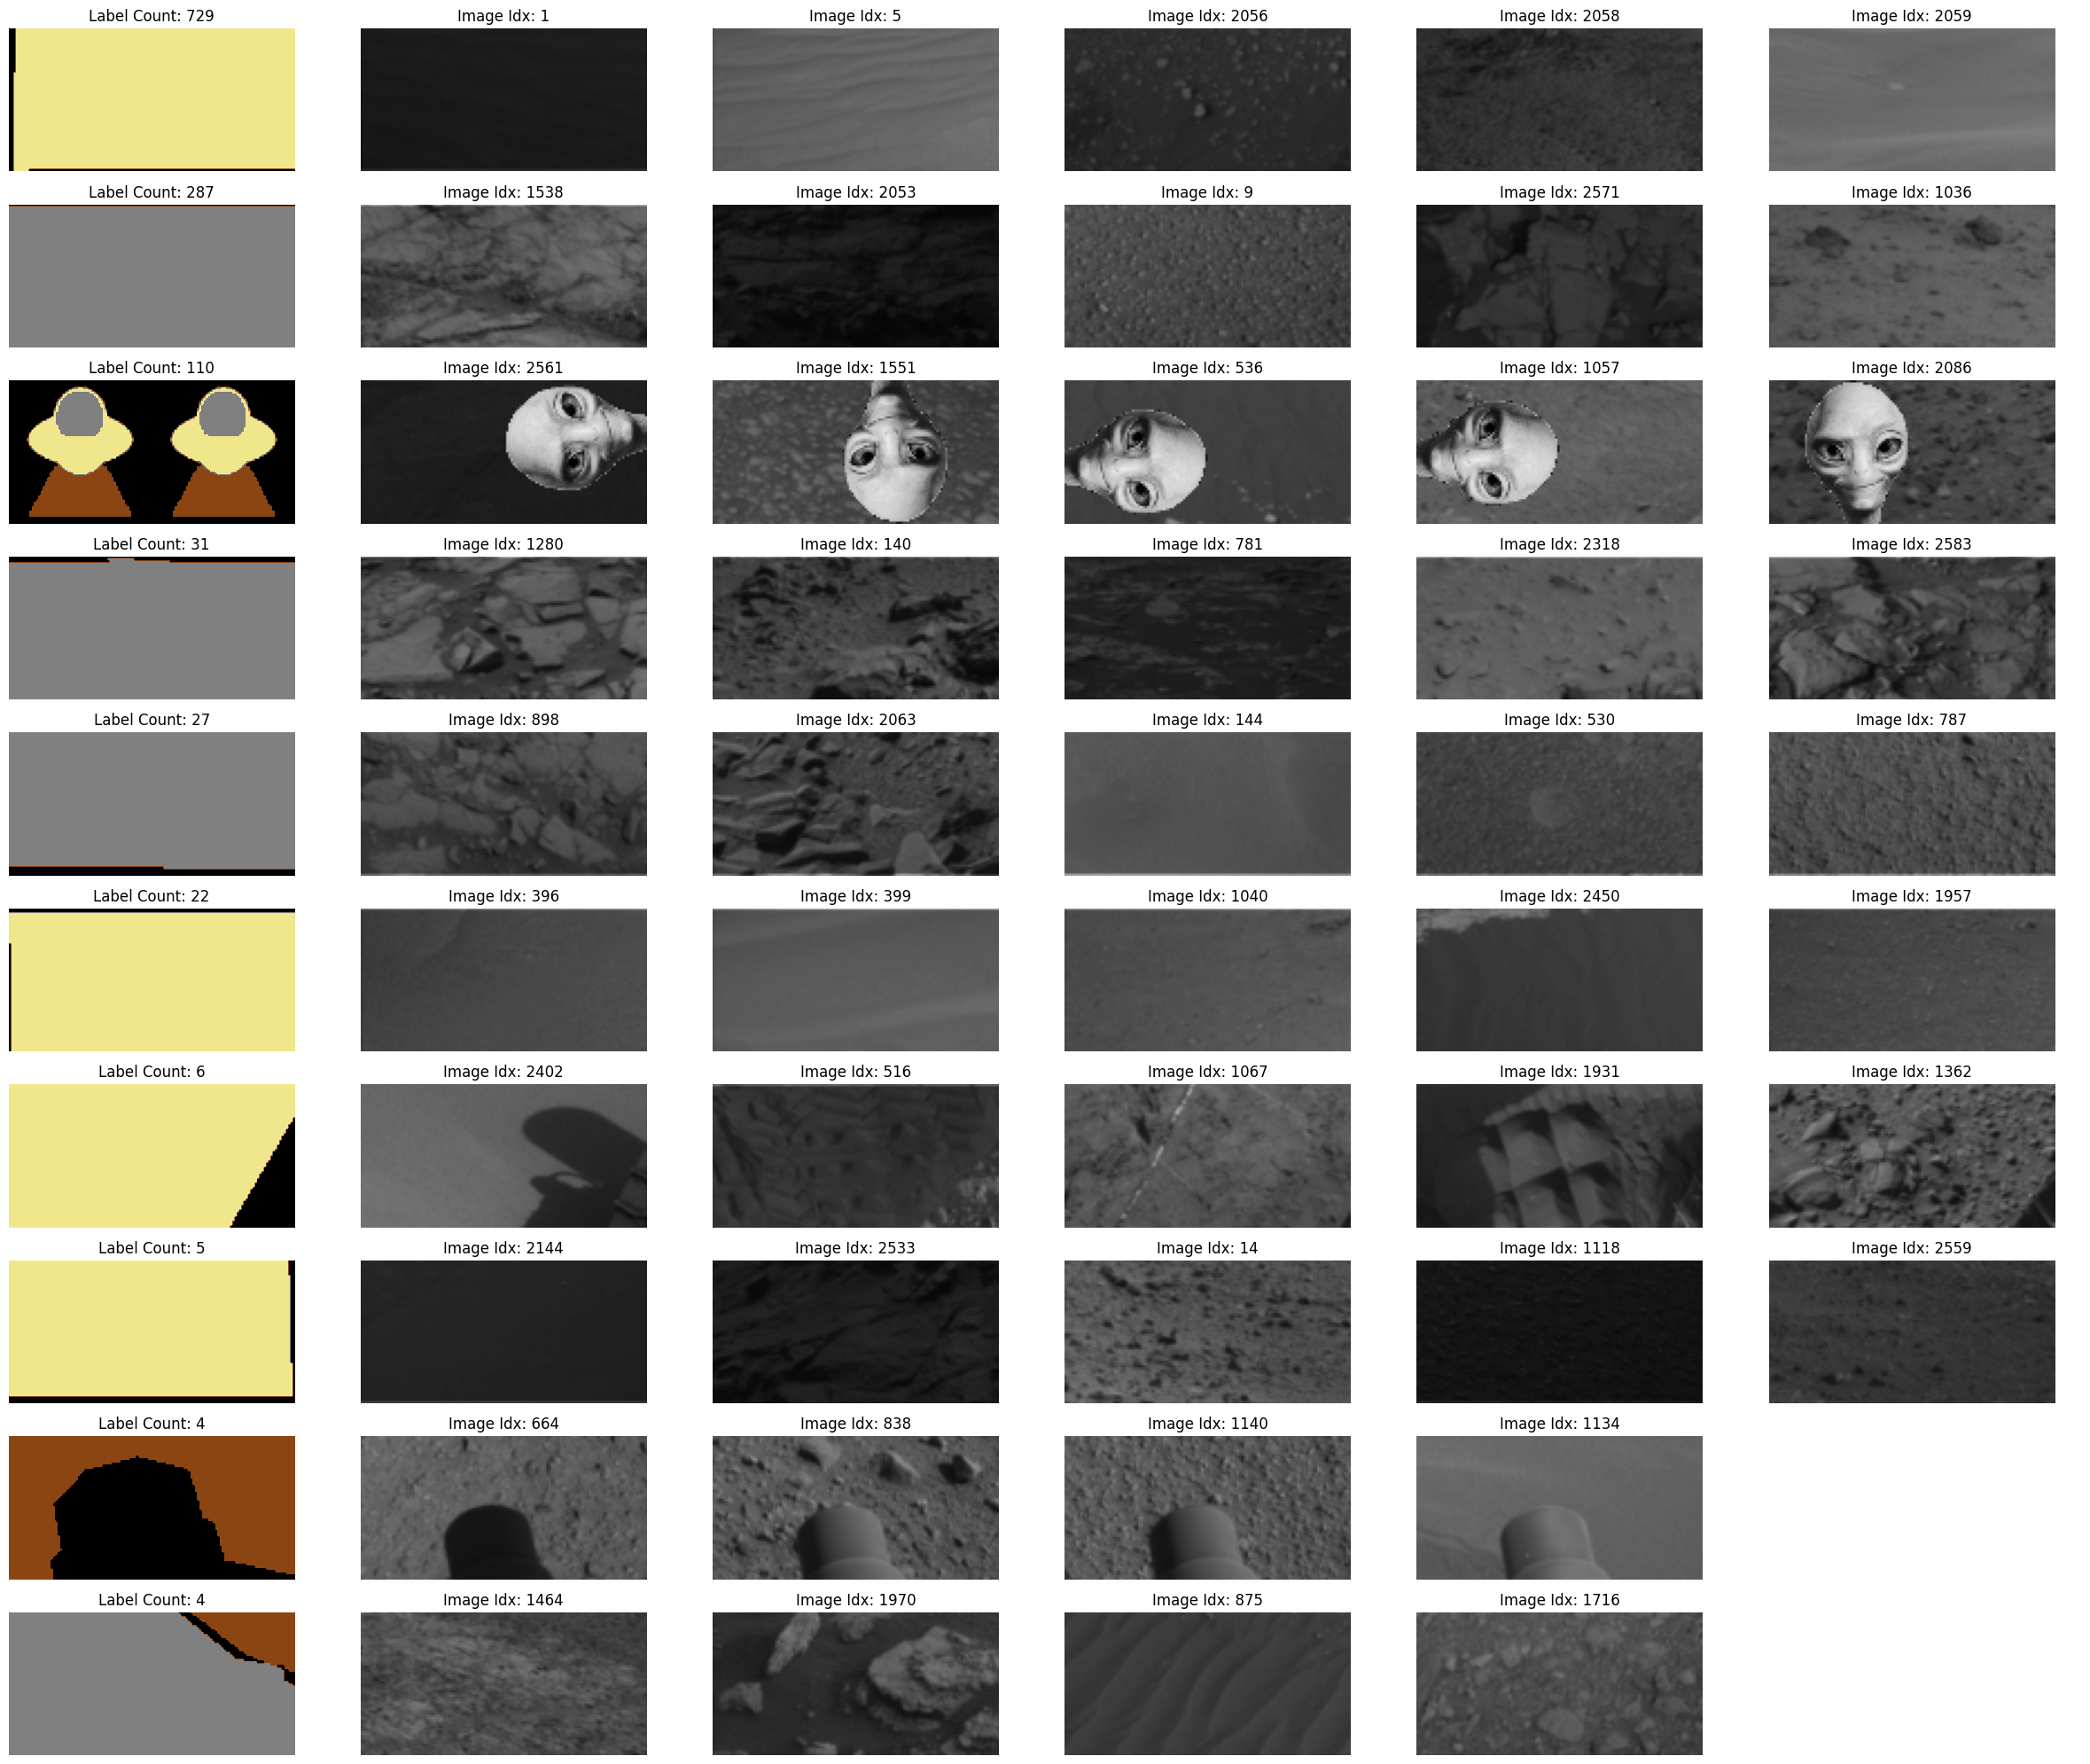

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

def find_duplicates_with_similarity(y_train, similarity_threshold=0.9):
    """
    Find duplicate groups based on similarity of label images.
    Returns a dictionary with key as tuple of similar indices, and value as count.
    """
    y_reshaped = y_train.reshape(y_train.shape[0], -1)
    
    # Compute pairwise cosine similarity
    similarity_matrix = cosine_similarity(y_reshaped)

    # Keep track of visited indices
    visited = set()
    duplicates_info = {}

    for i in range(len(similarity_matrix)):
        if i in visited:
            continue

        # Find all indices similar to the current label
        similar_indices = np.where(similarity_matrix[i] >= similarity_threshold)[0]
        similar_indices = set(similar_indices) - visited

        if len(similar_indices) > 1:  # Only consider groups with duplicates
            duplicates_info[tuple(similar_indices)] = len(similar_indices)

        # Mark these indices as visited
        visited.update(similar_indices)

    return duplicates_info

def plot_duplicates(X_train, y_train, duplicates_info, max_images=5, min_count=4):
    """
    Plot duplicates: Each row corresponds to a duplicate group with count >= min_count, 
    the label is shown once, and subsequent columns showing images. 
    Show all duplicates if count <= max_images, otherwise show up to max_images.
    """
    # Filter duplicates_info by min_count and sort by count in descending order
    filtered_duplicates = {indices: count for indices, count in duplicates_info.items() if count >= min_count}
    sorted_duplicates = sorted(filtered_duplicates.items(), key=lambda x: x[1], reverse=True)
    num_rows = len(sorted_duplicates)

    if num_rows == 0:
        print("No duplicate groups meet the minimum count requirement.")
        return

    # Create a grid for visualization (1 column for label, remaining for images)
    _, axes = plt.subplots(num_rows, max_images + 1, figsize=(4 * (max_images + 1), 2 * num_rows))

    if num_rows == 1:
        axes = np.array([axes])  # Ensure axes is 2D for single-row case

    for row, (indices, count) in enumerate(sorted_duplicates):
        # Show the label once in the first column
        label_idx = indices[0]
        axes[row, 0].imshow(y_train[label_idx], cmap=cmap, vmin=0, vmax=4)
        axes[row, 0].axis('off')
        axes[row, 0].set_title(f"Label Count: {count}")

        # Show images in subsequent columns
        num_to_plot = min(len(indices), max_images)
        for col in range(num_to_plot):
            idx = indices[col]
            axes[row, col + 1].imshow(X_train[idx], cmap='gray', vmin=0, vmax=255)
            axes[row, col + 1].axis('off')
            axes[row, col + 1].set_title(f"Image Idx: {idx}")

        # Turn off unused axes in the row
        for col in range(num_to_plot + 1, max_images + 1):
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

duplicates_info = find_duplicates_with_similarity(y_train_original, similarity_threshold=0.98)
plot_duplicates(X_train_original, y_train_original, duplicates_info, max_images=5, min_count=4)

In [5]:
# Let's remove the duplicates from the training set
def get_indices_to_remove(y_train, label_to_remove):
    y_reshaped = y_train.reshape(y_train.shape[0], -1)
    label_flat = label_to_remove.reshape(1, -1)
    indices_to_remove = np.where(np.all(y_reshaped == label_flat, axis=1))[0]
    return indices_to_remove

def remove_indices(X_train, y_train, indices_to_remove):
    mask = np.ones(X_train.shape[0], dtype=bool)  # Create a mask of all True
    mask[indices_to_remove] = False  # Set False for indices to remove
    X_train_new = X_train[mask]
    y_train_new = y_train[mask]
    return X_train_new, y_train_new

# The label to remove
label_to_remove = y_train_original[2561]  # Take one of the labels from the identified images containing the Alien

indices_to_remove = get_indices_to_remove(y_train_original, label_to_remove)
X_train_cleaned, y_train_cleaned = remove_indices(X_train_original, y_train_original, indices_to_remove)
print(f"Original train shape: {X_train_original.shape}, New shape: {X_train_cleaned.shape}")

X_train_original = X_train_cleaned
y_train_original = y_train_cleaned

Original train shape: (2615, 64, 128), New shape: (2505, 64, 128)


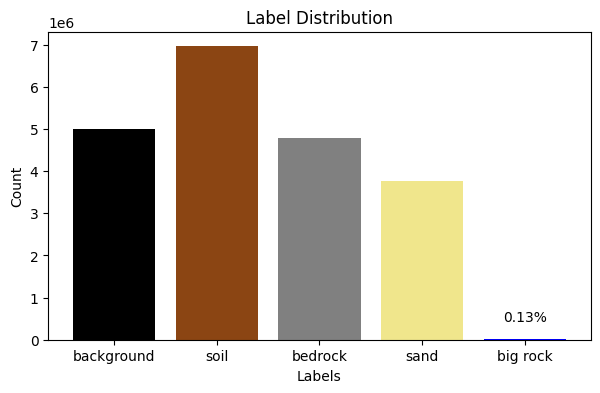

In [6]:
# Count the occurrences of each label
def plot_distribution(lbl):
    if isinstance(lbl, tf.Tensor):
        lbl = lbl.numpy()  # Convert TensorFlow tensor to NumPy

    label_counts = np.bincount(lbl.flatten().astype(int))
    total_count = np.sum(label_counts)
    # Compute percentage of label 4 (Big Rock)
    label_4_percentage = (label_counts[4] / total_count) * 100 if 4 < len(label_counts) else 0
    
    label_counts = np.bincount(lbl.flatten().astype(int))
    plt.figure(figsize=(7, 4))
    plt.bar(label_names, label_counts, color=colors)
    plt.xlabel("Labels")
    plt.ylabel("Count")
    plt.title("Label Distribution")

     # Annotate percentage for label 4
    if 4 < len(label_counts):  # Ensure label 4 exists
        plt.text(4, label_counts[4] + total_count * 0.02,  # Position above bar
                 f"{label_4_percentage:.2f}%", 
                 ha='center', fontsize=10)
        
    plt.show()

plot_distribution(y_train_original)

## Prepare the dataset

In [7]:
# Set batch size for training
BATCH_SIZE = 64
# Set learning rate for the optimiser
LEARNING_RATE = 1e-3
# Set early stopping patience threshold
PATIENCE = 30
# Set maximum number of training epochs
EPOCHS = 1000
# Set data split size for training and validation
SPLITS_SIZE = 300
# Set Seed
SEED = 42

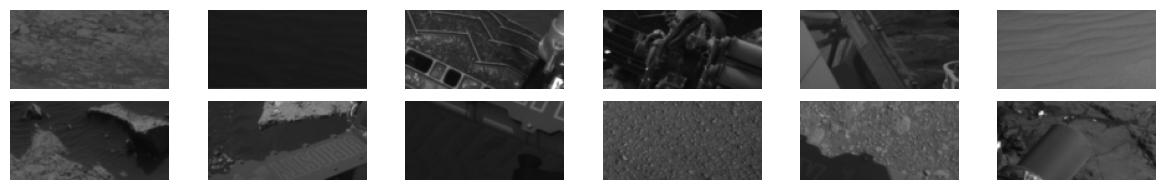

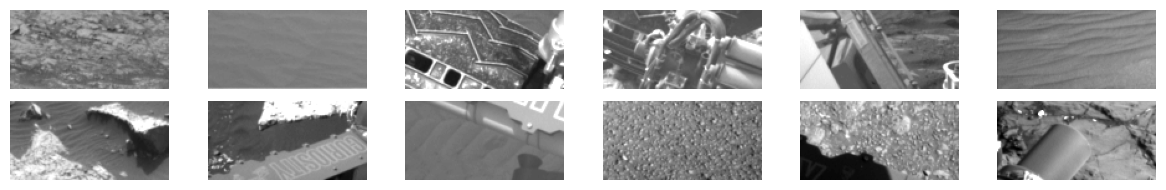

In [8]:
# Let's apply some preprocessing to the images (common for both training and test sets)
def apply_preprocessing(images):
    images = images[..., tf.newaxis] / 255.0
    ret = []
    for image in images:
        mean_brightness = tf.reduce_mean(image)
        delta = 1.0 * (0.5 - mean_brightness) # To adjust brightness to a mean of 0.5
        image = tf.image.adjust_brightness(image, delta=delta) 
        image = tf.image.adjust_contrast(image, contrast_factor=2.5)
        image = tf.clip_by_value(image, 0.0, 1.0) # Ensure pixel values are in [0, 1] after preprocessing
        ret.append(image)
    return np.array(ret)
    
plot_images(X_train_original, 2, 6, 255) # Plot before

X_train = apply_preprocessing(X_train_original)
y_train = y_train_original[..., tf.newaxis]

X_train = tf.cast(X_train, tf.float32)
y_train = tf.cast(y_train, tf.int32)

plot_images(X_train, 2, 6, 1) # Plot after

In [9]:
# Let's split the data into training and validation sets
train_img, val_img, train_lbl, val_lbl = train_test_split(X_train.numpy().squeeze(), y_train.numpy().squeeze(), test_size=SPLITS_SIZE)
print("Data splitted!")
print(f"\nNumber of images:")
print(f"Train: {len(train_img)}")
print(f"Validation: {len(val_img)}")

train_img = train_img[..., tf.newaxis]
val_img = val_img[..., tf.newaxis]
train_lbl = train_lbl[..., tf.newaxis]
val_lbl = val_lbl[..., tf.newaxis]

Data splitted!

Number of images:
Train: 2205
Validation: 300


In [10]:
# Let's create a function to augment 1 sample into n_aug_0123 or n_aug_4 samples
def augment_images(image, label, n_aug_0123, n_aug_4, seed=42):
    # Determine the number of augmentations based on the label content
    n_augmentations = tf.cond(
        tf.reduce_any(tf.equal(label, 4)),  # Check if label contains 4
        lambda: tf.constant(n_aug_4), 
        lambda: tf.constant(n_aug_0123)      
    )

    augmented_images = tf.TensorArray(dtype=tf.float32, size=n_augmentations+1)
    augmented_labels = tf.TensorArray(dtype=tf.float32, size=n_augmentations+1)
    
    augmented_images = augmented_images.write(0, image) # Keep original image
    augmented_labels = augmented_labels.write(0, label) # Keep original label

    for i in tf.range(1, n_augmentations+1):  # Loop based on the number of augmentations
        augmented_image, augmented_label = image, label

        # Apply random horizontal and vertical flips
        if tf.random.uniform(()) > 0.2:
            augmented_image = tf.image.flip_left_right(augmented_image)
            augmented_label = tf.image.flip_left_right(augmented_label)

        if tf.random.uniform(()) > 0.2:
            augmented_image = tf.image.flip_up_down(augmented_image)
            augmented_label = tf.image.flip_up_down(augmented_label)

        # Add Gaussian noise
        if tf.random.uniform(()) > 0.2:
            noise = tf.random.normal(shape=tf.shape(augmented_image), mean=0.0, stddev=0.01)
            augmented_image = tf.clip_by_value(augmented_image + noise, 0.0, 1.0)

        # Apply Zoom augmentation
        if tf.random.uniform(()) > 0.2:
            zoom_factor = tf.random.uniform([], minval=1, maxval=1.2, dtype=tf.float32, seed=seed)
            central_fraction = 1.0 / zoom_factor
            zoom_image = tf.image.central_crop(augmented_image, central_fraction)
            zoom_label = tf.image.central_crop(augmented_label, central_fraction)

            # Resize to original size
            augmented_image = tf.image.resize(zoom_image, tf.shape(image)[0:2])
            augmented_label = tf.image.resize(zoom_label, tf.shape(label)[0:2])

        # Append augmented image and label
        augmented_images = augmented_images.write(i, augmented_image)
        augmented_labels = augmented_labels.write(i, augmented_label)

    # Return stacked augmented images and labels
    return augmented_images.stack(), augmented_labels.stack()

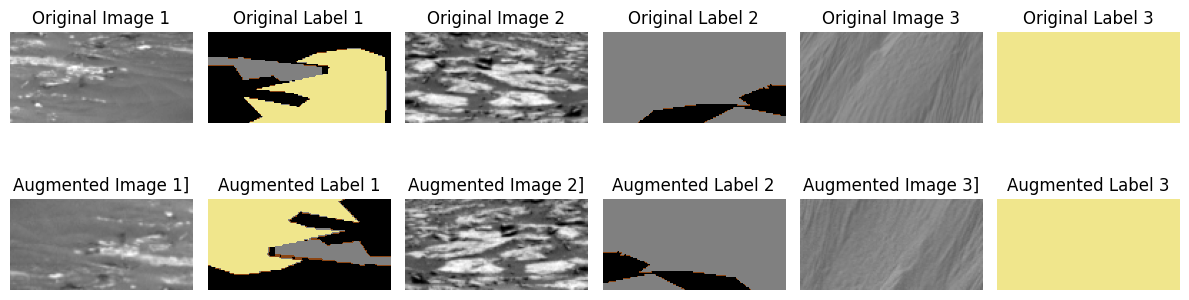

In [11]:
def plot_images_with_labels(images, labels, num_samples, augmentations):
    labels = tf.cast(labels, tf.float32)
    # Create a grid of plots: First row for original images and labels, followed by augmented rows
    num_rows = augmentations + 1  # 1 for the original images, N for augmented images
    _, axes = plt.subplots(num_rows, 2 * num_samples, figsize=(12, num_rows * 2))

    # Select random samples from x_train and y_train
    indices = tf.random.uniform([num_samples], minval=0, maxval=len(images), dtype=tf.int32)
    original_images = tf.gather(images, indices)
    original_labels = tf.gather(labels, indices)

    # Plot the original images and labels
    for i in range(num_samples):
        axes[0, 2 * i].imshow(original_images[i], cmap='gray', vmin=0, vmax=1)
        axes[0, 2 * i].set_title(f"Original Image {i + 1}")
        axes[0, 2 * i].axis('off')

        axes[0, 2 * i + 1].imshow(original_labels[i], cmap=cmap, vmin=0, vmax=4)
        axes[0, 2 * i + 1].set_title(f"Original Label {i + 1}")
        axes[0, 2 * i + 1].axis('off')

    # Plot the augmented images and labels
    for row in range(1, num_rows):
        for i in range(num_samples):
            # Apply augmentations and plot
            aug_images, aug_labels = augment_images(original_images[i], original_labels[i], 1, 1)
            augmented_image = aug_images[1] # Skip the original image and take the first augmentation
            augmented_label = aug_labels[1] # Skip the original label and take the first augmentation

            # Plot augmented image
            axes[row, 2 * i].imshow(augmented_image, cmap='gray', vmin=0, vmax=1)
            axes[row, 2 * i].set_title(f"Augmented Image {i + 1}]")
            axes[row, 2 * i].axis('off')

            # Plot augmented label
            axes[row, 2 * i + 1].imshow(augmented_label, cmap=cmap, vmin=0, vmax=4)
            axes[row, 2 * i + 1].set_title(f"Augmented Label {i + 1}")
            axes[row, 2 * i + 1].axis('off')

    plt.tight_layout()
    plt.show()

plot_images_with_labels(train_img, train_lbl, num_samples=3, augmentations=1)

In [12]:
def make_dataset(images, labels, batch_size, shuffle, augment=False, n_aug0123=1, n_aug_4=20, seed=SEED):
    # Create dataset from the samples
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    # Cast labels to float32 for augmentation compatibility
    dataset = dataset.map(lambda image, label: (image, tf.cast(label, tf.float32)), num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        def augmentation_map(image, label):
            augmented_images, augmented_labels = augment_images(image, label, n_aug0123, n_aug_4, seed=seed)
            # Flatten tensors directly to avoid graph scoping issues
            return tf.data.Dataset.from_tensor_slices((augmented_images, augmented_labels))
        # Apply augmentations with flat_map
        dataset = dataset.flat_map(augmentation_map)

    #Cast back labels to int32 after augmentation
    dataset = dataset.map(lambda image, label: (image, tf.cast(label, tf.int32)), num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=batch_size * 2, seed=seed) # Shuffle the dataset 

    # Batch the data and use data prefetching for faster processing
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

# Create the datasets
train_dataset = make_dataset(train_img, train_lbl, batch_size=BATCH_SIZE, shuffle=True, augment=True, n_aug0123=1, n_aug_4=1)
val_dataset = make_dataset(val_img, val_lbl, batch_size=BATCH_SIZE, shuffle=False) # Keep Shuffle False
print("Datasets created!")

# Check the shape of the data
for images, labels in train_dataset.take(1):
    input_shape = images.shape[1:]
    print(f"Input shape: {input_shape}")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    break

total_images = 0
for images, labels in train_dataset:
    total_images += images.shape[0]  # Count number of images in each batch

print(f"Total number of images in train_dataset: {total_images}")

Datasets created!
Input shape: (64, 128, 1)
Images shape: (64, 64, 128, 1)
Labels shape: (64, 64, 128, 1)
Total number of images in train_dataset: 4410


## 🛠️ Train and Save the Model

In [13]:
def unet_block(input_tensor, filters, kernel_size=3, activation='relu', stack=2, name=''):
    # Apply a sequence of Conv2D, Batch Normalisation, and Activation layers for the specified number of stacks
    x = input_tensor
    for i in range(stack):
        x = tfkl.Conv2D(filters, kernel_size=kernel_size, padding='same', name=name + 'conv' + str(i + 1))(x)
        x = tfkl.BatchNormalization(name=name + 'bn' + str(i + 1))(x)
        x = tfkl.Activation(activation, name=name + 'activation' + str(i + 1))(x)
    
    # Apply Dropout to regularize the model and help avoid overfitting (especially on the background class)
    x = tfkl.Dropout(0.3)(x)  # Dropout rate can be adjusted
    return x

def get_unet_model(input_shape, num_classes=5, seed=42):
    tf.random.set_seed(seed)
    input_layer = tfkl.Input(shape=input_shape, name='input_layer')

    # Downsampling path with increased filters
    down_block_1 = unet_block(input_layer, 64, name='down_block1_')
    d1 = tfkl.MaxPooling2D()(down_block_1)

    down_block_2 = unet_block(d1, 128, name='down_block2_')
    d2 = tfkl.MaxPooling2D()(down_block_2)

    # Bottleneck with increased filters
    bottleneck = unet_block(d2, 256, name='bottleneck')

    # Upsampling path with increased filters
    u1 = tfkl.UpSampling2D()(bottleneck)
    u1 = tfkl.Concatenate()([u1, down_block_2])
    u1 = unet_block(u1, 128, name='up_block1_')

    u2 = tfkl.UpSampling2D()(u1)
    u2 = tfkl.Concatenate()([u2, down_block_1])
    u2 = unet_block(u2, 64, name='up_block2_')

    # Output Layer with softmax activation
    output_layer = tfkl.Conv2D(num_classes, kernel_size=1, padding='same', activation="softmax", name='output_layer')(u2)

    # Create the model
    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name='UNet')
    
    return model

Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer       │ (None, 64, 128, │         0 │ -              │   -   │
│ (InputLayer)      │ 1)              │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ down_block1_conv1 │ (None, 64, 128, │       640 │ input_layer[0… │   Y   │
│ (Conv2D)          │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ down_block1_bn1   │ (None, 64, 128, │       256 │ down_block1_c… │   Y   │
│ (BatchNormalizat… │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ down_block1_acti… │ (None, 64, 128, │         0 │ down_block1_b… │   -   │
│ (Activation)      │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ down_block1_conv2 │ (None, 64, 128, │    36,928 │ down_block1_a… │   Y   │
│ (Conv2D)          │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ down_block1_bn2   │ (None, 64, 128, │       256 │ down_block1_c… │   Y   │
│ (BatchNormalizat… │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ down_block1_acti… │ (None, 64, 128, │         0 │ down_block1_b… │   -   │
│ (Activation)      │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 64, 128, │         0 │ down_block1_a… │   -   │
│                   │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ max_pooling2d     │ (None, 32, 64,  │         0 │ dropout[0][0]  │   -   │
│ (MaxPooling2D)    │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ down_block2_conv1 │ (None, 32, 64,  │    73,856 │ max_pooling2d… │   Y   │
│ (Conv2D)          │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ down_block2_bn1   │ (None, 32, 64,  │       512 │ down_block2_c… │   Y   │
│ (BatchNormalizat… │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ down_block2_acti… │ (None, 32, 64,  │         0 │ down_block2_b… │   -   │
│ (Activation)      │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ down_block2_conv2 │ (None, 32, 64,  │   147,584 │ down_block2_a… │   Y   │
│ (Conv2D)          │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ down_block2_bn2   │ (None, 32, 64,  │       512 │ down_block2_c… │   Y   │
│ (BatchNormalizat… │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ down_block2_acti… │ (None, 32, 64,  │         0 │ down_block2_b… │   -   │
│ (Activation)      │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 32, 64,  │         0 │ down_block2_a… │   -   │
│ (Dropout)         │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ max_pooling2d_1   │ (None, 16, 32,  │         0 │ dropout_1[0][… │   - 

 Total params: 1,887,365 (7.20 MB)

 Trainable params: 1,884,805 (7.19 MB)

 Non-trainable params: 2,560 (10.00 KB)

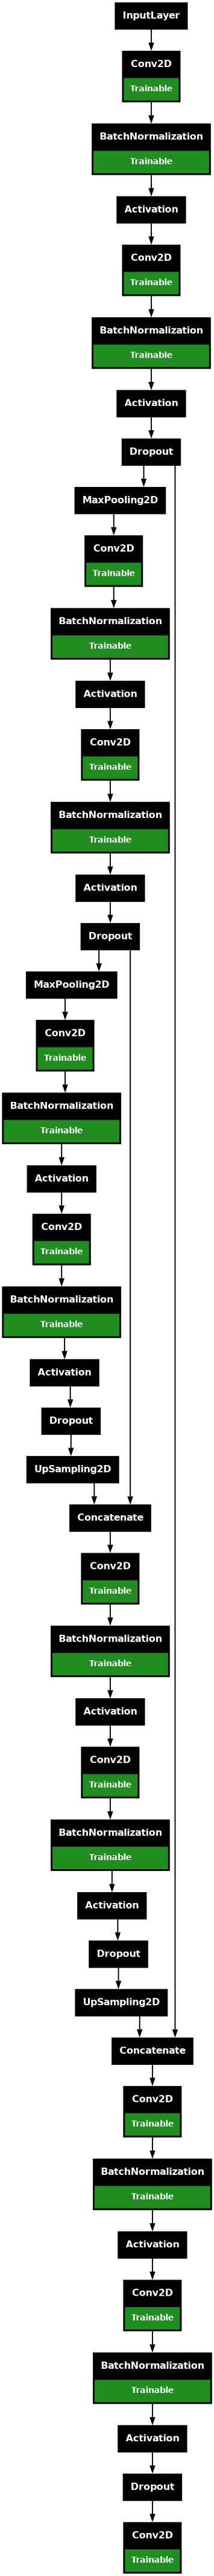

In [14]:
model = get_unet_model(input_shape=input_shape)

# Print a detailed summary of the model with expanded nested layers and trainable parameters.
model.summary(expand_nested=True, show_trainable=True)

# Generate and display a graphical representation of the model architecture.
tf.keras.utils.plot_model(model, to_file='/kaggle/working/model.png', show_trainable=True, expand_nested=True, dpi=70)

In [15]:
class VizCallback(tf.keras.callbacks.Callback):
    """ Custom Callback to visualize validation predictions during model training """
    def __init__(self, val_dataset, frequency, n):
        super().__init__()
        self.val_dataset = val_dataset  # Take the validation dataset
        self.frequency = frequency
        self.n = n

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.frequency == 0:  # Visualize only every "frequency" epochs
            # Extract a batch from the validation dataset
            val_batch = next(iter(self.val_dataset))  # Take one batch
            images, labels = val_batch  # Unbatch the data
            n = min(self.n, len(images))  # Ensure we don't exceed available images
            
            preds = self.model.predict(images, verbose=0)
            y_preds = tf.math.argmax(preds, axis=-1).numpy()  # Convert predictions to numpy

            # Determine rows and columns for plotting
            rows = (n + 1) // 2  # Calculate rows needed for 2 images per row
            plt.figure(figsize=(12, rows))

            for i in range(n):
                col = (i % 2) * 3  # Columns in each row (3 subplots per image)
                row = i // 2       # Current row

                # Input image
                plt.subplot(rows, 6, row * 6 + col + 1)
                plt.imshow(images[i], cmap='gray', vmin=0, vmax=1)
                plt.title(f"Input {i + 1}")
                plt.axis('off')

                # Ground truth
                plt.subplot(rows, 6, row * 6 + col + 2)
                plt.imshow(labels[i], cmap=cmap, vmin=0, vmax=4)
                plt.title(f"Ground Truth {i + 1}")
                plt.axis('off')

                # Prediction
                plt.subplot(rows, 6, row * 6 + col + 3)
                plt.imshow(y_preds[i], cmap=cmap, vmin=0, vmax=4)
                plt.title(f"Prediction {i + 1}")
                plt.axis('off')

            plt.tight_layout()
            plt.show()
            plt.close()

Model compiled!
Epoch 1/1000


I0000 00:00:1734174678.041641      71 service.cc:145] XLA service 0x7ea9b8011620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1734174678.041711      71 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1734174678.041717      71 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
W0000 00:00:1734174678.470008      71 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


      1/Unknown 74s 74s/step - accuracy: 0.1228 - loss: 2.2897 - mean_iou: 0.0561

I0000 00:00:1734174744.573549      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


     68/Unknown 81s 111ms/step - accuracy: 0.4048 - loss: 1.5532 - mean_iou: 0.2142

W0000 00:00:1734174752.450869      69 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


     69/Unknown 203s 2s/step - accuracy: 0.4064 - loss: 1.5490 - mean_iou: 0.2151  

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)
W0000 00:00:1734174874.570596      72 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1734174875.651484      70 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


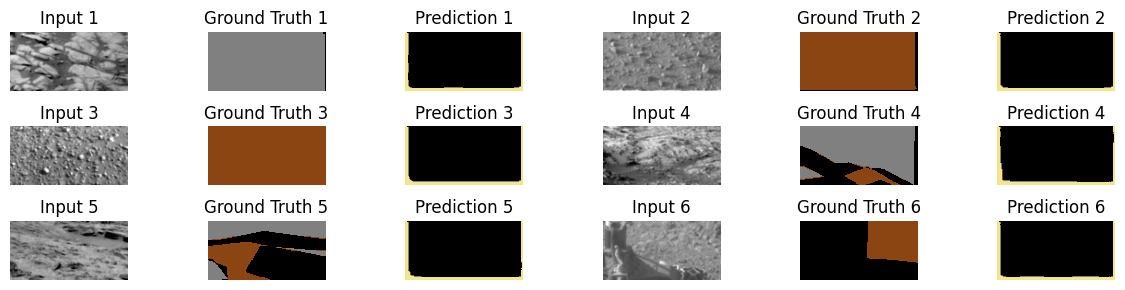

69/69 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.4079 - loss: 1.5450 - mean_iou: 0.2161 - val_accuracy: 0.2284 - val_loss: 6.4305 - val_mean_iou: 0.0138 - learning_rate: 0.0010
Epoch 2/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.5965 - loss: 1.0574 - mean_iou: 0.3308 - val_accuracy: 0.2211 - val_loss: 5.4016 - val_mean_iou: 0.0191 - learning_rate: 0.0010
Epoch 3/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.6304 - loss: 0.9669 - mean_iou: 0.3538 - val_accuracy: 0.2171 - val_loss: 3.6098 - val_mean_iou: 0.0715 - learning_rate: 0.0010
Epoch 4/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.6496 - loss: 0.9230 - mean_iou: 0.3672 - val_accuracy: 0.2178 - val_loss: 2.0253 - val_mean_iou: 0.0576 - learning_rate: 0.0010
Epoch 5/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.6572 - loss: 0.8963 - mean_iou: 0.3750 - val_accuracy: 0.2865 - val_loss: 2.2275 - val_mean_iou: 0.1033 - learning_rate: 0.0010
Epoch 6/1000
69/69 ━━━━━━━━━━━━━

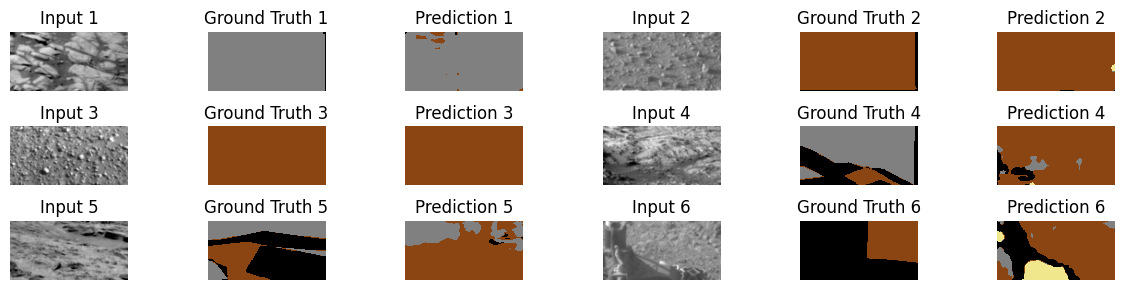

69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.6988 - loss: 0.7903 - mean_iou: 0.4123 - val_accuracy: 0.5802 - val_loss: 1.4991 - val_mean_iou: 0.3114 - learning_rate: 0.0010
Epoch 12/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.6973 - loss: 0.7896 - mean_iou: 0.4115 - val_accuracy: 0.6281 - val_loss: 1.0855 - val_mean_iou: 0.3244 - learning_rate: 0.0010
Epoch 13/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.7091 - loss: 0.7675 - mean_iou: 0.4204 - val_accuracy: 0.5581 - val_loss: 1.5737 - val_mean_iou: 0.2655 - learning_rate: 0.0010
Epoch 14/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.7094 - loss: 0.7636 - mean_iou: 0.4201 - val_accuracy: 0.5641 - val_loss: 1.0733 - val_mean_iou: 0.2714 - learning_rate: 0.0010
Epoch 15/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.7107 - loss: 0.7545 - mean_iou: 0.4170 - val_accuracy: 0.6078 - val_loss: 1.2576 - val_mean_iou: 0.3031 - learning_rate: 0.0010
Epoch 16/1000
69/69 ━━━━━━━━

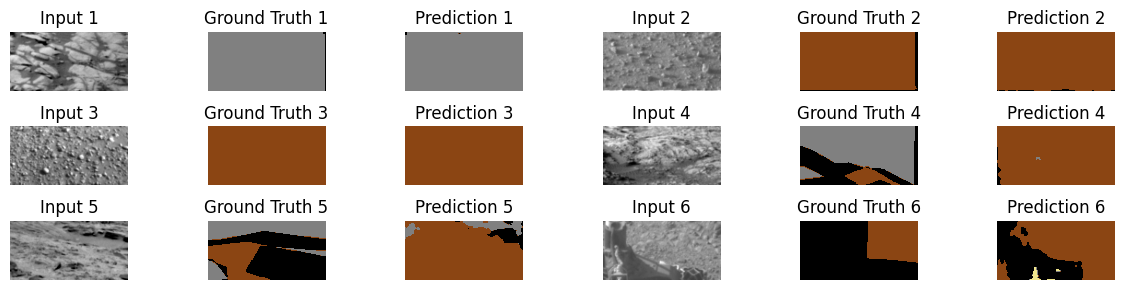

69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - accuracy: 0.7257 - loss: 0.7150 - mean_iou: 0.4348 - val_accuracy: 0.6344 - val_loss: 1.0618 - val_mean_iou: 0.3236 - learning_rate: 0.0010
Epoch 22/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.7306 - loss: 0.7070 - mean_iou: 0.4367 - val_accuracy: 0.5853 - val_loss: 0.9987 - val_mean_iou: 0.2747 - learning_rate: 0.0010
Epoch 23/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.7386 - loss: 0.6881 - mean_iou: 0.4441 - val_accuracy: 0.6175 - val_loss: 1.0446 - val_mean_iou: 0.2904 - learning_rate: 0.0010
Epoch 24/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.7367 - loss: 0.6942 - mean_iou: 0.4435 - val_accuracy: 0.5866 - val_loss: 1.2302 - val_mean_iou: 0.2580 - learning_rate: 0.0010
Epoch 25/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.7417 - loss: 0.6825 - mean_iou: 0.4504 - val_accuracy: 0.6169 - val_loss: 0.9586 - val_mean_iou: 0.3381 - learning_rate: 0.0010
Epoch 26/1000
69/69 ━━━━━━━━

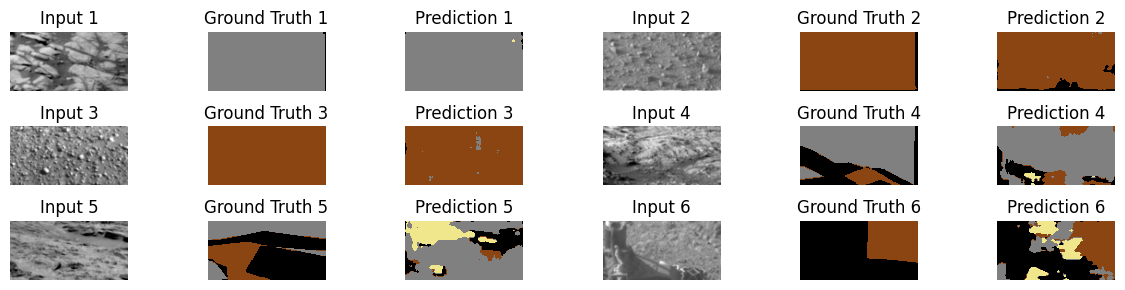

69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.7520 - loss: 0.6513 - mean_iou: 0.4581 - val_accuracy: 0.6126 - val_loss: 1.2376 - val_mean_iou: 0.3218 - learning_rate: 0.0010
Epoch 32/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.7540 - loss: 0.6419 - mean_iou: 0.4608 - val_accuracy: 0.6285 - val_loss: 1.3337 - val_mean_iou: 0.3315 - learning_rate: 0.0010
Epoch 33/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7536 - loss: 0.6474 - mean_iou: 0.4579
Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.7537 - loss: 0.6473 - mean_iou: 0.4579 - val_accuracy: 0.6039 - val_loss: 1.3102 - val_mean_iou: 0.3105 - learning_rate: 0.0010
Epoch 34/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.7629 - loss: 0.6210 - mean_iou: 0.4699 - val_accuracy: 0.6942 - val_loss: 0.8335 - val_mean_iou: 0.3854 - learning_rate: 5.0000e-04
Epoch 35/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/

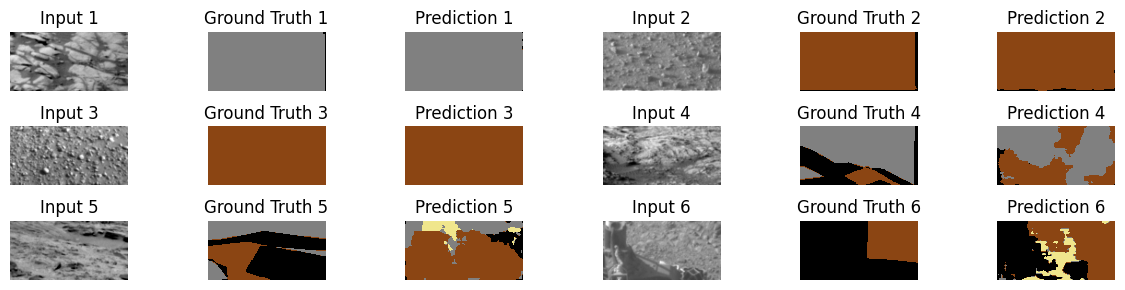

69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.7767 - loss: 0.5808 - mean_iou: 0.4859 - val_accuracy: 0.6642 - val_loss: 0.8704 - val_mean_iou: 0.3728 - learning_rate: 5.0000e-04
Epoch 42/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.7757 - loss: 0.5831 - mean_iou: 0.4785 - val_accuracy: 0.6545 - val_loss: 0.8638 - val_mean_iou: 0.3675 - learning_rate: 5.0000e-04
Epoch 43/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.7776 - loss: 0.5817 - mean_iou: 0.4798 - val_accuracy: 0.6828 - val_loss: 0.8721 - val_mean_iou: 0.4030 - learning_rate: 5.0000e-04
Epoch 44/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.7794 - loss: 0.5739 - mean_iou: 0.4877
Epoch 44: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.7795 - loss: 0.5739 - mean_iou: 0.4876 - val_accuracy: 0.6604 - val_loss: 0.8985 - val_mean_iou: 0.3781 - learning_rate: 5.0000e-04
Epoch 45/1000
69/69 ━━━━━━━━━━━━━━━━━━

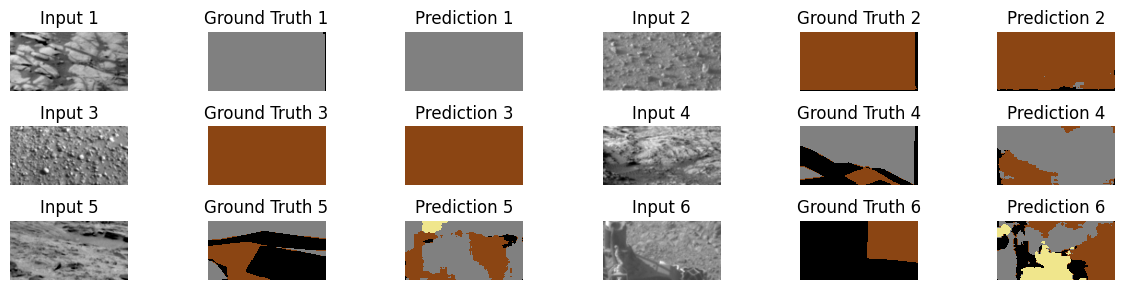

69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - accuracy: 0.7937 - loss: 0.5346 - mean_iou: 0.4949 - val_accuracy: 0.6561 - val_loss: 0.9324 - val_mean_iou: 0.3921 - learning_rate: 2.5000e-04
Epoch 52/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.7942 - loss: 0.5351 - mean_iou: 0.4973 - val_accuracy: 0.6452 - val_loss: 1.0690 - val_mean_iou: 0.3780 - learning_rate: 1.2500e-04
Epoch 53/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.7995 - loss: 0.5198 - mean_iou: 0.5015 - val_accuracy: 0.6717 - val_loss: 0.9436 - val_mean_iou: 0.3993 - learning_rate: 1.2500e-04
Epoch 54/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.7960 - loss: 0.5301 - mean_iou: 0.4975 - val_accuracy: 0.6626 - val_loss: 0.9899 - val_mean_iou: 0.3945 - learning_rate: 1.2500e-04
Epoch 55/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.7998 - loss: 0.5175 - mean_iou: 0.5009 - val_accuracy: 0.6527 - val_loss: 1.0494 - val_mean_iou: 0.3843 - learning_rate: 1.2500e-04
Epoch 56

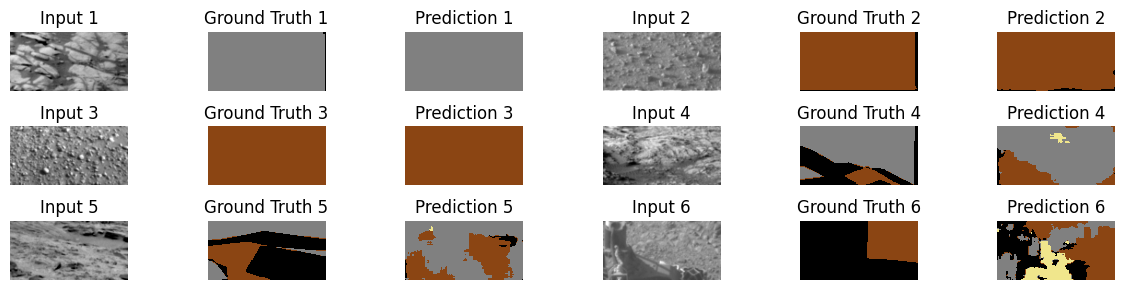

69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - accuracy: 0.8039 - loss: 0.5071 - mean_iou: 0.5030 - val_accuracy: 0.6771 - val_loss: 0.9184 - val_mean_iou: 0.4066 - learning_rate: 6.2500e-05
Epoch 62/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.8027 - loss: 0.5127 - mean_iou: 0.5007 - val_accuracy: 0.6798 - val_loss: 0.9092 - val_mean_iou: 0.4135 - learning_rate: 6.2500e-05
Epoch 63/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.8056 - loss: 0.5048 - mean_iou: 0.5038 - val_accuracy: 0.6774 - val_loss: 0.9192 - val_mean_iou: 0.4109 - learning_rate: 6.2500e-05
Epoch 64/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.8062 - loss: 0.5029 - mean_iou: 0.5067 - val_accuracy: 0.6823 - val_loss: 0.9006 - val_mean_iou: 0.4157 - learning_rate: 6.2500e-05
Epoch 65/1000
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8069 - loss: 0.4995 - mean_iou: 0.5050
Epoch 65: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
69/69 ━━━━━━━━━━━━━━━━━━

In [16]:
mean_iou = tfk.metrics.MeanIoU(num_classes=5, ignore_class=0, sparse_y_pred=False, name='mean_iou')

# Compile the model
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.AdamW(LEARNING_RATE),
    metrics=["accuracy", mean_iou]
)
print("Model compiled!")

# Setup callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5, verbose=1
)

n = 6 # Number of images to visualize during training
viz_callback = VizCallback(val_dataset, frequency=10, n=n)

# Train the model
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[lr_scheduler, early_stopping, viz_callback],
    verbose=1
).history

# Calculate and print the final validation mean IoU
final_val_meanIoU = round(max(history['val_mean_iou'])* 100, 2)
print(f'Final validation Mean Intersection Over Union: {final_val_meanIoU}%')

In [17]:
model_filename = f'First_UNet_{str(final_val_meanIoU)}_aug4.keras'

if (on_kaggle):
    model_filename = f"/kaggle/working/{model_filename}"

model.save(model_filename)
print(f"Model saved to {model_filename}")

Model saved to /kaggle/working/First_UNet_42.32_aug4.keras


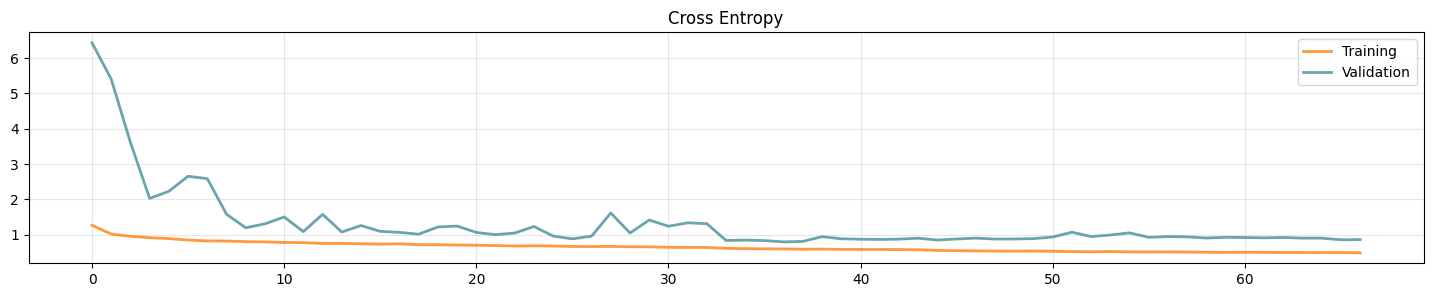

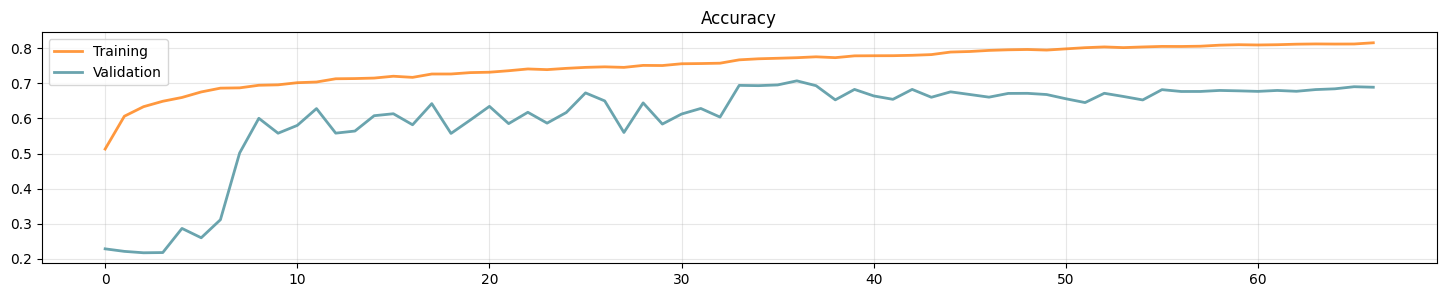

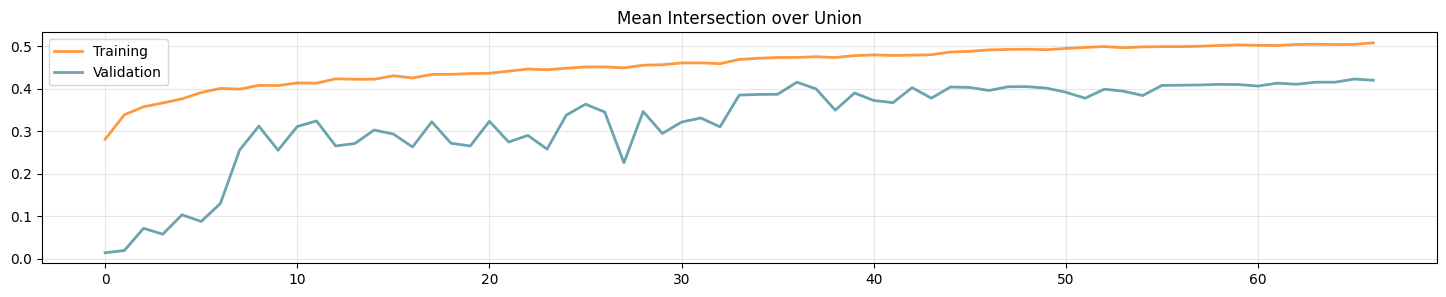

In [18]:
# Plot and display training and validation loss
plt.figure(figsize=(18, 3))
plt.plot(history['loss'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_loss'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Cross Entropy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot and display training and validation accuracy
plt.figure(figsize=(18, 3))
plt.plot(history['accuracy'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_accuracy'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot and display training and validation mean IoU
plt.figure(figsize=(18, 3))
plt.plot(history['mean_iou'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_mean_iou'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Mean Intersection over Union')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 📊 Prepare Submission


Model loaded from /kaggle/working/First_UNet_42.32_aug4.keras
314/314 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step
Predictions shape: (10022, 64, 128)
Class counts: [12413642 31178246 18298026 20210310        0]


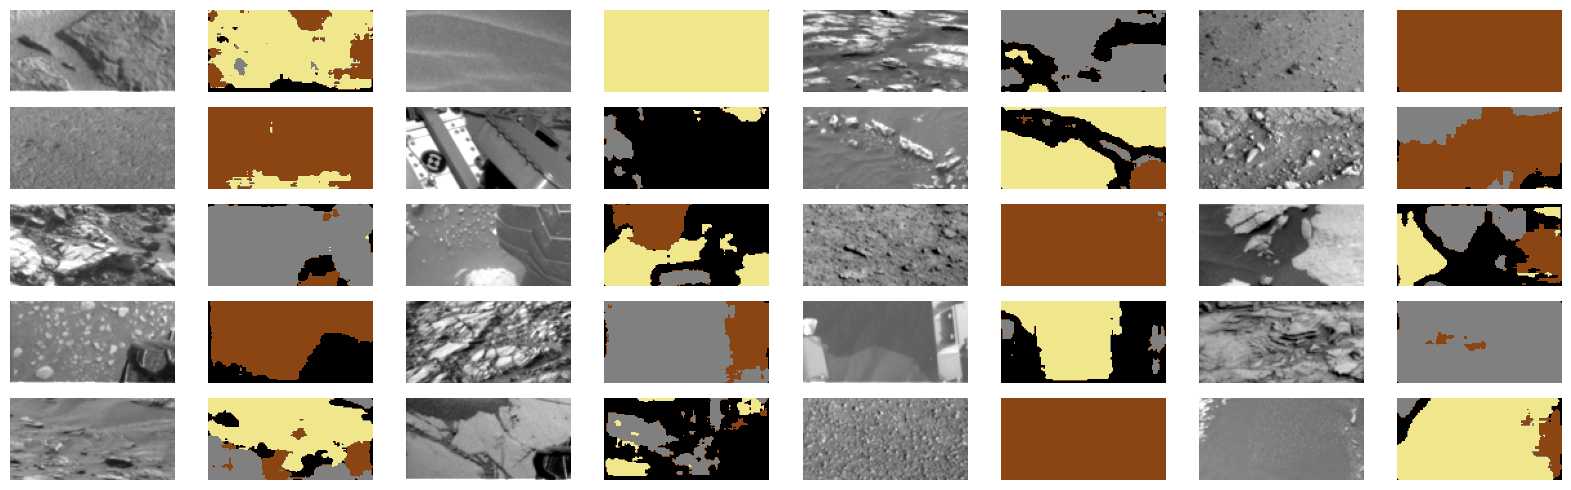

In [19]:
model_pred = tfk.models.load_model(model_filename)
print(f"Model loaded from {model_filename}")

# Apply preprocessing to the test set
X_test = apply_preprocessing(X_test_original) 
X_test = tf.cast(X_test, tf.float32)

preds = model_pred.predict(X_test) # Predict on the test set
preds = np.argmax(preds, axis=-1)
class_counts = np.bincount(preds.flatten(), minlength=5) # Count the occurrences of each class per pixel

print(f"Predictions shape: {preds.shape}")
print(f"Class counts: {class_counts}")
plot_image_label(X_test, preds, 5, 4, 1) # Plot the predictions

In [20]:
def y_to_df(y) -> pd.DataFrame:
    """Converts segmentation predictions into a DataFrame format for Kaggle."""
    n_samples = len(y)
    y_flat = y.reshape(n_samples, -1)
    df = pd.DataFrame(y_flat)
    df["id"] = np.arange(n_samples)
    cols = ["id"] + [col for col in df.columns if col != "id"]
    return df[cols]

# Create the csv submission file
submission_df = y_to_df(preds)
submission_filename = model_filename.replace(".keras", ".csv")
zip_filename = model_filename.replace(".keras", ".zip")
submission_df.to_csv(submission_filename, index=False)


with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    filename = submission_filename.replace("/kaggle/working/", "")
    zipf.write(submission_filename, arcname=filename)  # Add the CSV directly to the zip

# Delete the CSV file after it's added to the zip
os.remove(submission_filename)
print("Zip file with CSV created successfully!")

Zip file with CSV created successfully!
